### Load the Cleaned Dataset

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Shrabani P\IronHack\Week6_Day2\Project_3\Project3_amazon-review-insights\data\processed\amazon_reviews_cleaned.csv", low_memory=False)

df.head()

,id,name,brand,categories,asins,reviews.rating,reviews.title,reviews.text,reviews.username,reviews.date
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Kindle,This product so far has not disappointed. My c...,Adapter,2017-01-13 00:00:00+00:00
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,very fast,great for beginner or experienced person. Boug...,truman,2017-01-13 00:00:00+00:00
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,DaveZ,2017-01-13 00:00:00+00:00
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Shacks,2017-01-13 00:00:00+00:00
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,explore42,2017-01-12 00:00:00+00:00


### Dataset overview 

In [92]:
df.shape

(59741, 10)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59741 entries, 0 to 59740
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                59741 non-null  object 
 1   name              59741 non-null  object 
 2   brand             59741 non-null  object 
 3   categories        59741 non-null  object 
 4   asins             59741 non-null  object 
 5   reviews.rating    59741 non-null  float64
 6   reviews.title     59741 non-null  object 
 7   reviews.text      59741 non-null  object 
 8   reviews.username  59741 non-null  object 
 9   reviews.date      59600 non-null  object 
dtypes: float64(1), object(9)
memory usage: 4.6+ MB


In [94]:
df["reviews.date"] = pd.to_datetime(df["reviews.date"], errors="coerce")

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59741 entries, 0 to 59740
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                59741 non-null  object             
 1   name              59741 non-null  object             
 2   brand             59741 non-null  object             
 3   categories        59741 non-null  object             
 4   asins             59741 non-null  object             
 5   reviews.rating    59741 non-null  float64            
 6   reviews.title     59741 non-null  object             
 7   reviews.text      59741 non-null  object             
 8   reviews.username  59741 non-null  object             
 9   reviews.date      59600 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(1), object(8)
memory usage: 4.6+ MB


In [96]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,59741,88,AVphgVaX1cnluZ0-DR74,10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,59741,119,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",10962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,59741,7,Amazon,42685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories,59741,101,"Fire Tablets,Tablets,Computers & Tablets,All T...",10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asins,59741,91,B018Y229OU,10966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.rating,59741.0,NaN,NaN,NaN,4.548903,1.0,4.0,5.0,5.0,5.0,0.837044
reviews.title,59741,25700,Five Stars,3332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.text,59741,46874,"A great Christmas gift, the kids love the gift...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.username,59741,36851,ByAmazon Customer,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.date,59600,NaN,NaN,NaN,2016-11-23 14:34:29.971023104+00:00,2009-02-26 00:00:00+00:00,2016-07-16 00:00:00+00:00,2016-12-30 00:00:00+00:00,2017-03-21 00:00:00+00:00,2019-03-25 00:00:00+00:00,NaN


In [97]:
df.isnull().sum()

id                    0
name                  0
brand                 0
categories            0
asins                 0
reviews.rating        0
reviews.title         0
reviews.text          0
reviews.username      0
reviews.date        141
dtype: int64

### Creating a new column

In [98]:
df["review_length"] = df["reviews.text"].str.split().str.len()

df.to_csv(
    "../data/processed/amazon_reviews_features.csv",
    index=False
)

In [99]:
duplicates = df.duplicated(
    subset=["id","reviews.text","reviews.rating"]
).sum()

print(duplicates)

0


### Brand vs Average Rating

In [100]:
brand_rating = (
    df.groupby("brand")["reviews.rating"]
      .mean()
)
print(brand_rating)

brand
Amazon                          4.568514
Amazon Digital Services Inc.    3.500000
Amazon Echo                     4.531447
Amazon Fire                     4.558594
Amazon Fire Tv                  4.707278
AmazonBasics                    4.300000
Amazonbasics                    4.403139
Name: reviews.rating, dtype: float64


In [101]:
df["brand"] = df["brand"].replace({
    "Amazonbasics": "AmazonBasics"
})

In [102]:
brand_rating = (
    df.groupby("brand", as_index=False)["reviews.rating"]
      .mean()
)

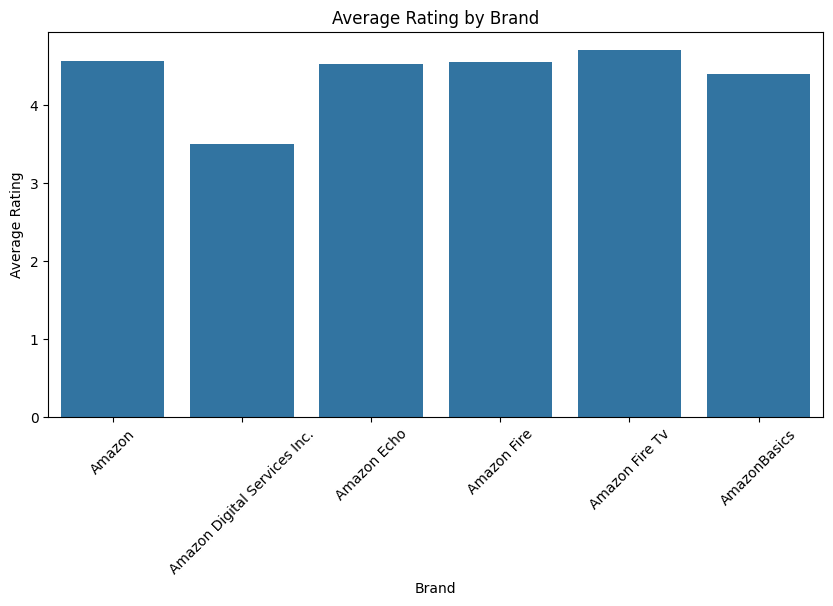

In [103]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=brand_rating,
    x="brand",
    y="reviews.rating"
)

plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.title("Average Rating by Brand")

plt.show()

In [104]:
print(df["brand"].unique())

['Amazon' 'Amazon Fire' 'Amazon Echo' 'Amazon Fire Tv'
 'Amazon Digital Services Inc.' 'AmazonBasics']


In [105]:
df["brand"].value_counts()

brand
Amazon                          42685
AmazonBasics                    11098
Amazon Fire Tv                   5056
Amazon Echo                       636
Amazon Fire                       256
Amazon Digital Services Inc.       10
Name: count, dtype: int64

In [106]:
df["brand"].nunique()

6

### During preprocessing, inconsistent categorical labels were standardized. Specifically, the brand names AmazonBasics and Amazonbasics were merged into a single category to ensure consistent analysis. As a result, the cleaned dataset contains 6 unique brands, whereas the original merged dataset contained 7 brand labels due to inconsistent capitalization.

In [107]:
df.to_csv(
    "../data/processed/amazon_reviews_cleaned_v2.csv",
    index=False
)

### Number of reviews by brand (Counts)

### 

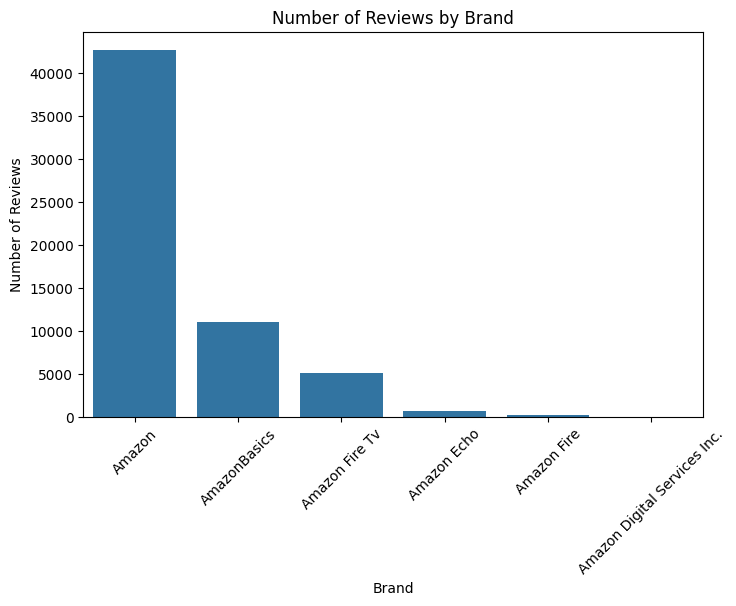

In [108]:
brand_counts = df["brand"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values)

plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews by Brand")
plt.show()

### Top 10 most-reviewed products

In [109]:
df_products = df[df["name"] != "Unknown Product"]

In [110]:
top_products = (
    df_products["name"]
    .value_counts()
    .head(10)
)

print(top_products)

name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                       10962
AmazonBasics AAA Performance Alkaline Batteries (36 Count)                                                    7555
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary                                3443
Echo (White),,,\r\nEcho (White),,,                                                                            3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,     3176
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                       2814
Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,                                                                        2527
Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers                             2435
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Off

) missing from font(s) DejaVu Sans.rograms\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


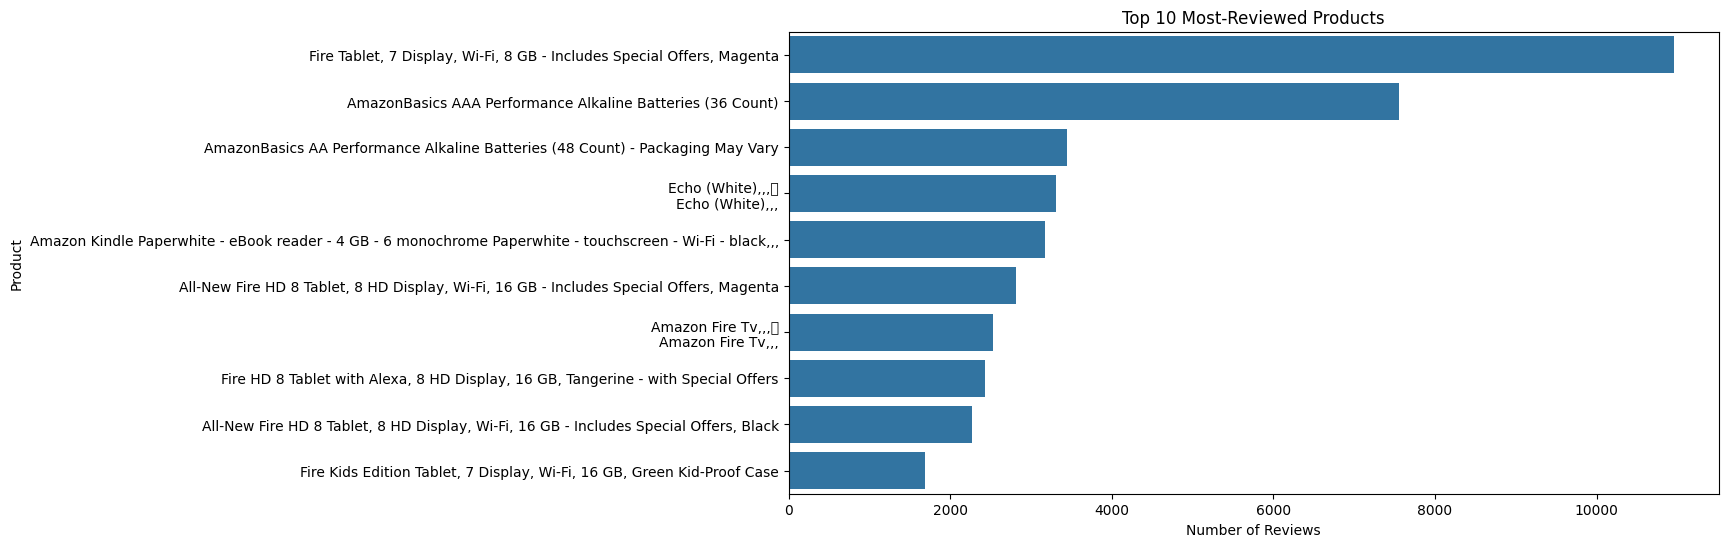

In [111]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.title("Top 10 Most-Reviewed Products")

plt.show()

### Top 10 Most-Reviewed Products by Average Rating

) missing from font(s) DejaVu Sans.rograms\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


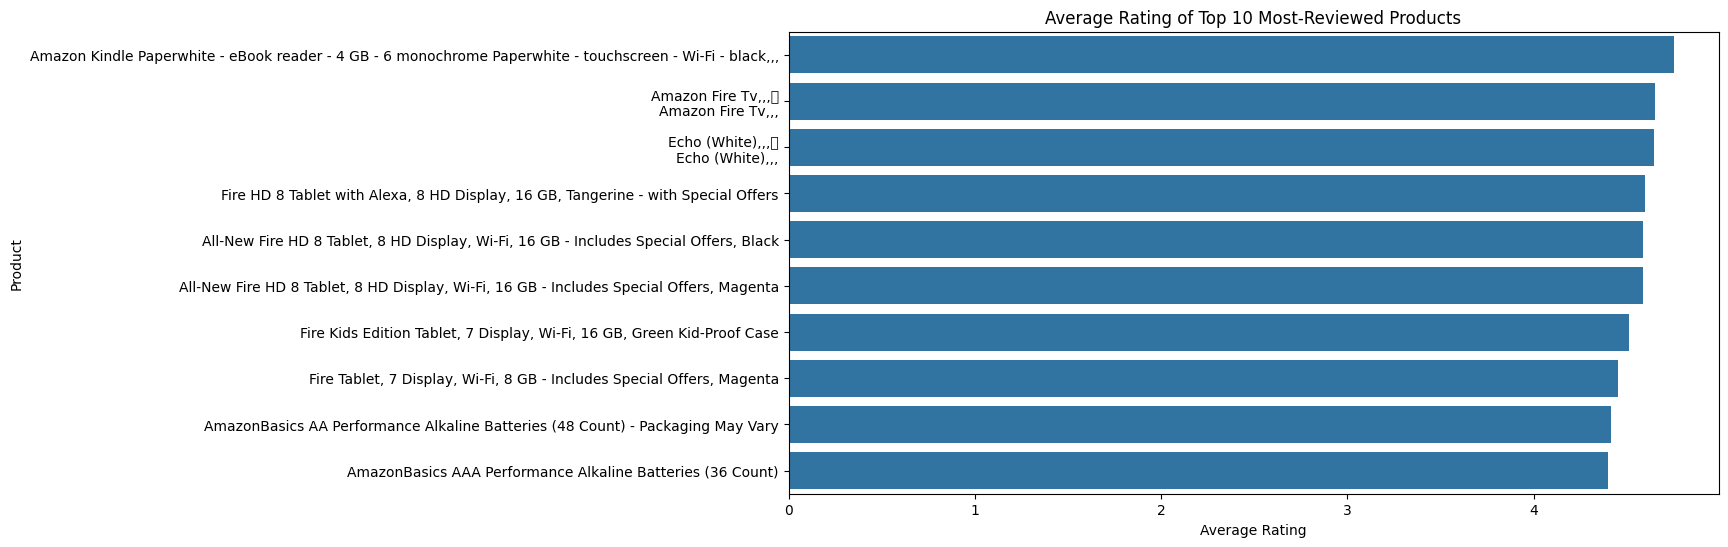

In [112]:
top10_names = top_products.index

top10_rating = (
    df[df["name"].isin(top10_names)]
      .groupby("name", as_index=False)["reviews.rating"]
      .mean()
      .sort_values(by="reviews.rating", ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_rating,
    x="reviews.rating",
    y="name"
)

plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.title("Average Rating of Top 10 Most-Reviewed Products")

plt.show()

### The Amazon Kindle Paperwhite received the highest average rating among the ten most-reviewed products. Overall, all of the top-reviewed products have average ratings above 4.4, indicating a high level of customer satisfaction across Amazon's most popular products.

### Review Length vs Rating

<Axes: xlabel='reviews.rating', ylabel='review_length'>

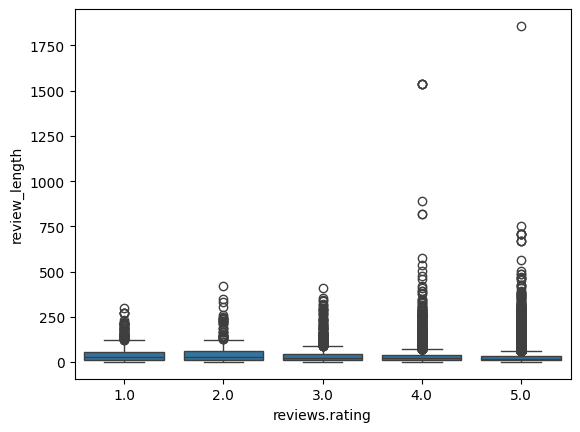

In [113]:
sns.boxplot(
    data=df,
    x="reviews.rating",
    y="review_length"
)

### The median review length is fairly similar across all ratings (1–5).
The horizontal line inside each box (the median) doesn't change much.
Ratings of 4 and 5 have many more long-review outliers.
There are many reviews with 200, 500, or even over 1,000 words for 4-star and 5-star ratings.
These extreme long reviews are much less common for 1-, 2-, and 3-star ratings.
The spread is larger for higher ratings.
Customers giving 4 or 5 stars vary more in how much they write.

### Reviews over time

In [114]:
df["review_year"] = df["reviews.date"].dt.year

In [115]:
reviews_per_year = (
    df["review_year"]
    .value_counts()
    .sort_index()
)

print(reviews_per_year)

review_year
2009.0        2
2011.0        2
2012.0        1
2013.0        4
2014.0       75
2015.0     4818
2016.0    25382
2017.0    27840
2018.0     1467
2019.0        9
Name: count, dtype: int64


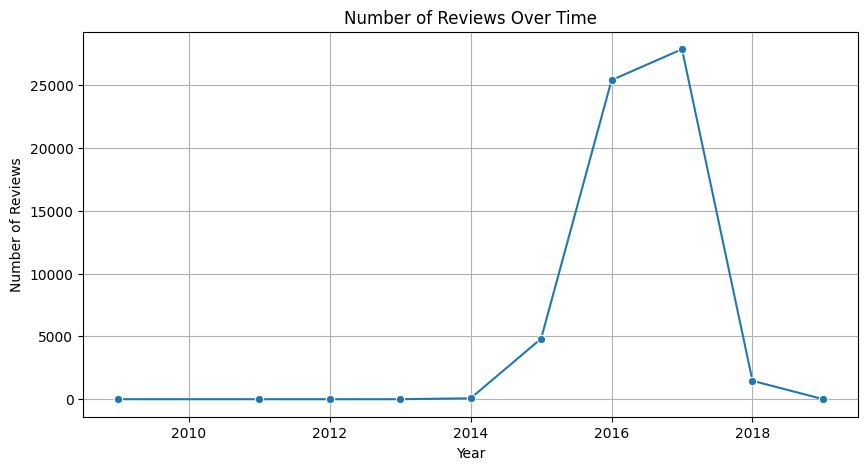

In [116]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=reviews_per_year.index,
    y=reviews_per_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews Over Time")

plt.grid(True)

plt.show()

### The number of reviews increased substantially between 2015 and 2017, with 2017 containing the highest review volume. After 2017, the number of reviews declines sharply. This trend likely reflects the period during which the dataset was collected rather than actual changes in customer activity.

### Word Cloud

In [119]:
!pip install wordcloud

  Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl (307 kB)


In [120]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = " ".join(df["reviews.text"].dropna().astype(str))

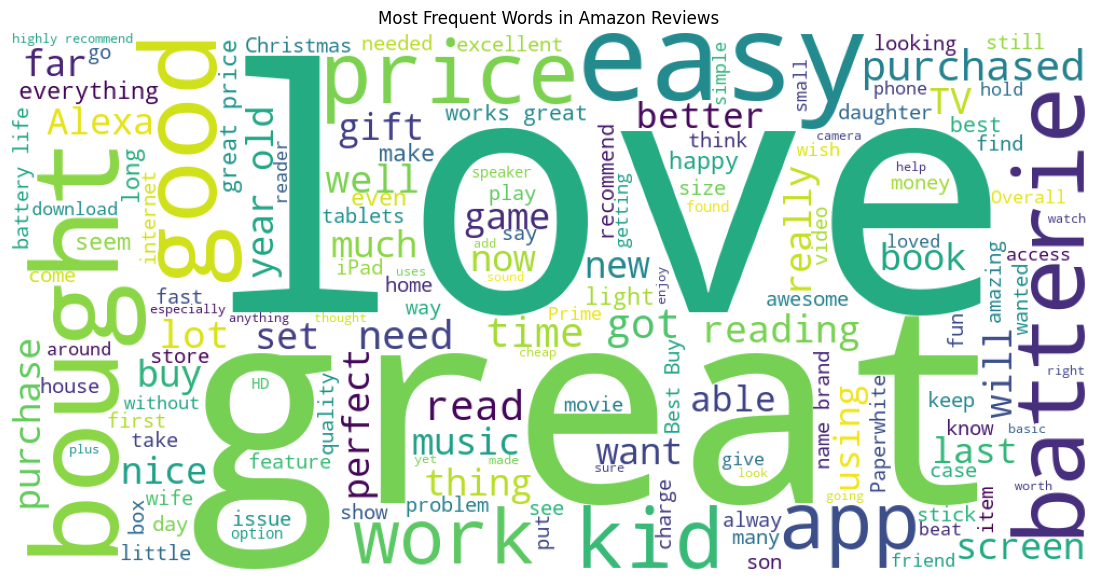

In [121]:
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)

# Add domain-specific words that don't add much insight
stopwords.update([
    "amazon",
    "kindle",
    "fire",
    "echo",
    "tablet",
    "device",
    "product",
    "one",
    "use",
    "used",
    "get",
    "would"
])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stopwords,
    max_words=150
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Amazon Reviews")
plt.show()

### Top 20 Most Frequent Words

In [122]:
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Shrabani
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [123]:
stop_words = set(stopwords.words("english"))

stop_words.update([
    "amazon",
    "kindle",
    "fire",
    "echo",
    "tablet",
    "device",
    "product",
    "one",
    "would",
    "get",
    "use",
    "used"
])

In [125]:
words = []

for review in df["reviews.text"].dropna():
    for word in review.lower().split():
        word = word.strip(".,!?;:\"'()[]")
        if word not in stop_words and len(word) > 2:
            words.append(word)

word_counts = Counter(words)

top20 = word_counts.most_common(20)
print(top20)

[('great', 19848), ('good', 10100), ('love', 9732), ('price', 8836), ('easy', 8661), ('batteries', 7957), ('bought', 7846), ('like', 6018), ('well', 4761), ('kids', 4721), ('works', 4466), ('loves', 4430), ('buy', 4357), ('much', 4231), ('time', 4040), ('apps', 4006), ('old', 3877), ('really', 3637), ('read', 3634), ('screen', 3574)]


In [126]:
import pandas as pd

top20_df = pd.DataFrame(
    top20,
    columns=["Word", "Frequency"]
)

top20_df

,Word,Frequency
0,great,19848
1,good,10100
2,love,9732
3,price,8836
4,easy,8661
5,batteries,7957
6,bought,7846
7,like,6018
8,well,4761
9,kids,4721


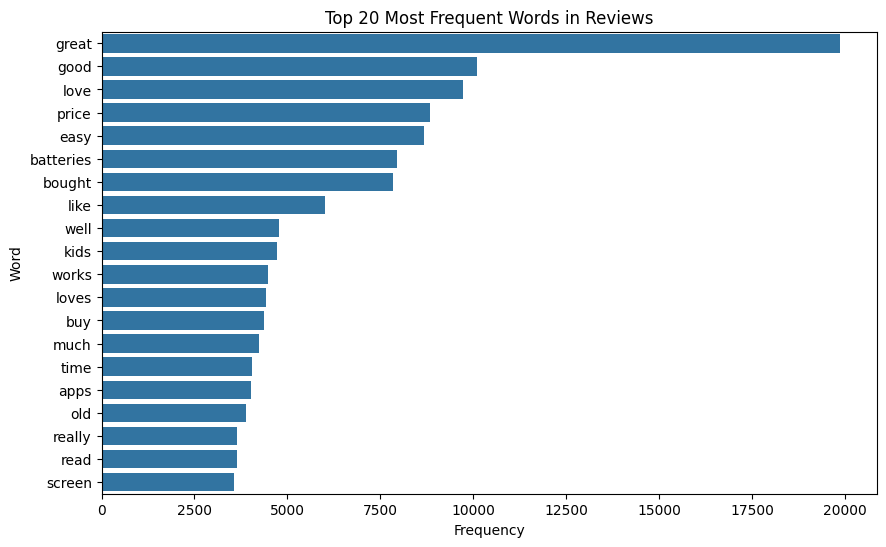

In [127]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()